![alt text](<../img/Portada - Modelado.png>)
# Modelado

Importamos las librerías adecuadas para poder realizar el apartado del Modelado

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor # Para el baseline más simple
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Métricas y utilidades
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

import warnings; warnings.filterwarnings('ignore')


Cargamos los datos del joblib:

In [2]:
# Cargamos los datos procesados
X_train, X_test, y_train, y_test = joblib.load('../data_sample/processed/datos_procesados.pkl')

print("¡Datos cargados con éxito!")
print(f"Columnas listas para el modelo: {X_train.columns.tolist()}")


¡Datos cargados con éxito!
Columnas listas para el modelo: ['kilometraje (km)', 'marca', 'modelo', 'combustible', 'transmisión', 'tipo de oferta', 'caballos de fuerza (CV)', 'año', 'antigüedad', 'km_anuales', 'gama_marca']


---

### Establecemos un Baseline

Escogiendo un modelo de Regresión Lineal

In [3]:
# Entrenamos el Baseline
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Predicciones
y_pred_base = baseline_model.predict(X_test)


In [4]:
# Métricas rápidas
mae_base = mean_absolute_error(y_test, y_pred_base)
r2_base = r2_score(y_test, y_pred_base)

print(f"Baseline (Regresión Lineal):")
print(f"MAE: {mae_base:.2f} €")
print(f"R2: {r2_base:.4f}")

Baseline (Regresión Lineal):
MAE: 4541.09 €
R2: 0.7670


---

### Pruebas con varios modelos y comparativas

In [5]:
# Definimos los modelos en un diccionario para iterar fácilmente
modelos = {
    "Regresión Lineal (Base)": LinearRegression(),
    "Árbol de Decisión": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN (k=5)": KNeighborsRegressor()
}

resultados = []

for nombre, modelo in modelos.items():
    # Entrenar
    modelo.fit(X_train, y_train)
    # Predecir
    y_pred = modelo.predict(X_test)
    
    # Calcular métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    resultados.append({
        "Modelo": nombre,
        "MAE (€)": round(mae, 2),
        "RMSE (€)": round(rmse, 2),
        "R2 Score": round(r2, 4)
    })

# Convertimos a DataFrame
df_comparativa = pd.DataFrame(resultados).sort_values(by="R2 Score", ascending=False)
display(df_comparativa)

,Modelo,MAE (€),RMSE (€),R2 Score
2,Random Forest,1983.76,5266.65,0.9030
3,Gradient Boosting,2508.04,5394.69,0.8982
1,Árbol de Decisión,2755.57,7333.08,0.8120
0,Regresión Lineal (Base),4541.09,8162.43,0.7670
4,KNN (k=5),5514.45,10381.51,0.6231


A la vista de los resultados obtenidos en la tabla superior, procedemos a detallar las conclusiones del benchmarking:

1. **El Ganador: Random Forest ($R^2 = 0.9030$)**
* Es el modelo más robusto. Conseguir un **MAE de 1.983 €** en un mercado donde hay coches de más de 100.000 € es un éxito rotundo.
* Al ser un conjunto de 100 árboles, promedia las predicciones y evita que los coches muy raros o "caros" desvíen la tasación. Es el modelo que mejor ha entendido la relación entre la **gama de la marca** y la **potencia**.


2. **El Aspirante: Gradient Boosting ($R^2 = 0.8982$)**
* Se ha quedado a las puertas. Aunque es muy potente, en este caso el Random Forest ha gestionado ligeramente mejor el ruido de los datos. Aun así, un MAE de 2.508 € sigue siendo una predicción muy fiable.


3. **El Problema de la Simplicidad: Árbol de Decisión ($R^2 = 0.8120$)**
* Vemos una caída de casi 10 puntos respecto al Random Forest. Esto demuestra que **un solo árbol no es suficiente**. Probablemente esté sufriendo de *overfitting* (memoriza mucho el entrenamiento pero falla más al ver coches nuevos en el test).


4. **El Fracaso del KNN ($R^2 = 0.6231$)**
* Este es el "farolillo rojo". Su error es de **5.514 €**, lo cual es inaceptable para tasar un coche.
* Como comentamos en el preprocesado, KNN se basa en distancias. Al no haber escalado todas las variables numéricas, los **Kilómetros** (números muy grandes) han "asfixiado" a otras variables importantes como la **Antigüedad**, arruinando la predicción.

Hemos desarrollado un sistema de tasación basado en **Random Forest** que permite valorar vehículos con un error medio de **1.983 €**. Teniendo en cuenta que el precio medio de los coches en el dataset ronda los 20.000 - 30.000 €, estamos ante un error inferior al 10%, lo que lo convierte en una herramienta altamente fiable para profesionales del sector compraventa.


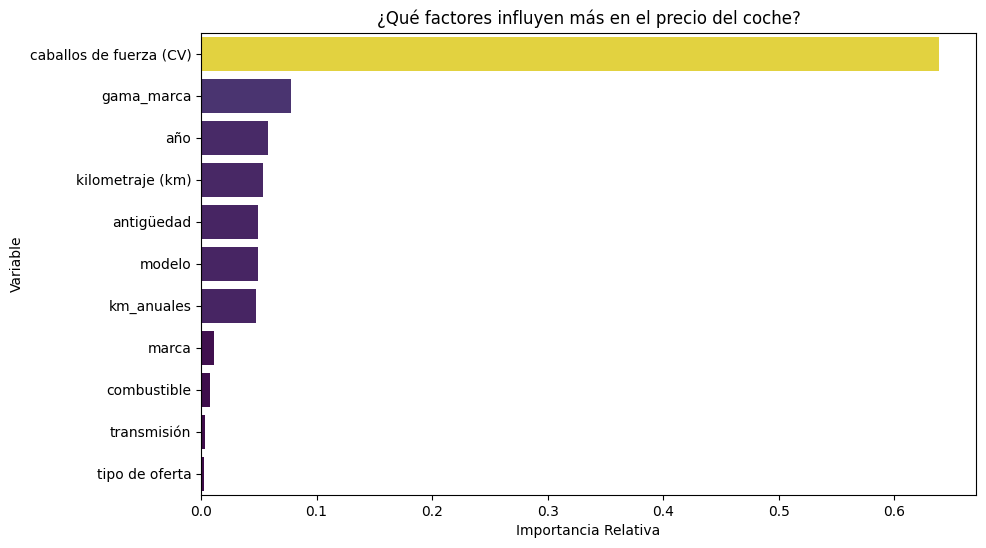

In [6]:
# Extraemos la importancia de las variables del modelo ganador
rf_model = modelos["Random Forest"]
importancias = rf_model.feature_importances_
nombres_features = X_train.columns

# Lo metemos en un DataFrame para que sea fácil de pintar
df_importancia = pd.DataFrame({'Feature': nombres_features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# Creamos la gráfica
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia',
    hue = 'Importancia', 
    y='Feature', 
    data=df_importancia, 
    palette='viridis',
    legend=False)

plt.title('¿Qué factores influyen más en el precio del coche?')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.show()

- Dominancia de la Potencia: Los CV representan el 60% de la importancia, siendo el principal factor de segmentación de precios.

- Eficacia de la Ingeniería de Variables: La variable creada gama_marca se posiciona como el segundo factor más relevante, validando la estrategia de agrupar fabricantes por su posicionamiento en el mercado.

- Factores Temporales: La combinación de año y antigüedad suma un peso crítico en la predicción, capturando la depreciación natural del activo. El modelo está repartiendo la importancia entre ellas. Para la optimización, probaremos a quitar año y dejar solo antigüedad.

- Variables con baja relevancia: El tipo de oferta o el combustible tienen un impacto marginal, lo que sugiere que en el mercado de segunda mano alemán, el estado técnico (CV y Km) y la categoría de la marca priman sobre el tipo de contrato o carburante.

--- 

### Optimización de hiperparámetros

In [7]:
# 1. Refinamos los datos quitando la columna redundante
X_train_ref = X_train.drop(columns=['año'])
X_test_ref = X_test.drop(columns=['año'])

In [8]:
from sklearn.model_selection import RandomizedSearchCV

# 2. Definimos el espacio de búsqueda
param_dist = {
    'n_estimators': [100, 200, 400], # ¿Más árboles ayudan a promediar mejor?
    'max_depth': [10, 20, 30, None], # Controlamos la complejidad
    'min_samples_split': [2, 5, 10], # Evitamos que el modelo se fije en detalles ínfimos
    'min_samples_leaf': [1, 2, 4],   # Suavizamos las predicciones
    'max_features': ['sqrt', 'log2', None] # Cuántas columnas mira cada árbol
}

# 3. Lanzamos el buscador (RandomizedSearchCV es más rápido que GridSearch)
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=15, # Probamos 15 combinaciones aleatorias
    cv=3,      # Validación cruzada de 3 carpetas
    scoring='neg_mean_absolute_error', # Queremos bajar el error en euros
    n_jobs=-1, 
    verbose=1,
    random_state=42
)

random_search.fit(X_train_ref, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 400]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [9]:
# 4. El "Mejor de la clase"
best_rf = random_search.best_estimator_
print(f"Mejores parámetros: {random_search.best_params_}")

Mejores parámetros: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}


- n_estimators: 400: El modelo ha decidido cuadruplicar el número de árboles. Esto significa que ahora promedia las decisiones de 400 expertos en vez de 100, lo que reduce muchísimo el error por "ruido" o coches con precios extraños.

- max_features: 'sqrt': Al usar solo la raíz cuadrada de las variables en cada división, los árboles se vuelven más diferentes entre sí. Esto evita que la Potencia (CV), que mandaba tanto, eclipse al resto de variables en cada decisión, permitiendo que la gama o los kilómetros también aporten su "granito de arena".

- max_depth: 30: Es una profundidad considerable, lo que permite al modelo captar matices muy específicos (como ediciones especiales o modelos muy concretos) sin llegar al sobreajuste total.

In [10]:
# 1. Definimos el modelo con los parámetros ganadores
best_rf = random_search.best_estimator_

# 2. Hacemos las nuevas predicciones (usamos el set ref, sin 'año')
y_pred_final = best_rf.predict(X_test_ref)

# 3. Calculamos métricas finales
r2_final = r2_score(y_test, y_pred_final)
mae_final = mean_absolute_error(y_test, y_pred_final)


In [11]:
print(f"--- RESULTADOS TRAS LA OPTIMIZACIÓN ---")
print(f"R2 Score Final: {r2_final:.4f}")
print(f"MAE Final: {mae_final:.2f} €")

--- RESULTADOS TRAS LA OPTIMIZACIÓN ---
R2 Score Final: 0.9332
MAE Final: 1925.00 €


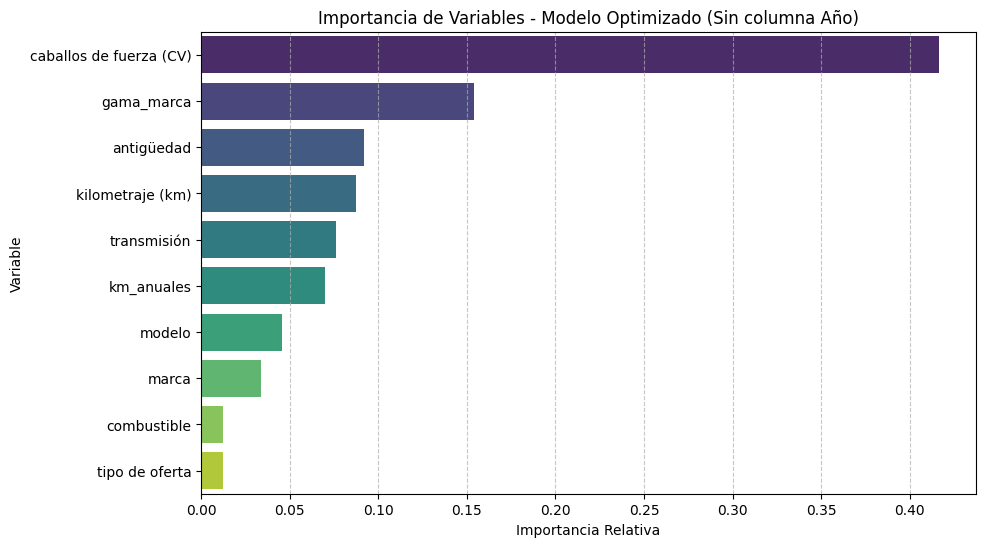

In [12]:
# 1. Extraemos las importancias del mejor modelo
importancias_opt = best_rf.feature_importances_
# Usamos las columnas de X_train_ref (el que no tiene 'año')
nombres_features_opt = X_train_ref.columns

# 2. Creamos el DataFrame para la gráfica
df_imp_opt = pd.DataFrame({'Feature': nombres_features_opt, 'Importancia': importancias_opt})
df_imp_opt = df_imp_opt.sort_values(by='Importancia', ascending=False)

# 3. Graficamos
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia', 
    y='Feature', 
    data=df_imp_opt, 
    palette='viridis', 
    hue='Feature', 
    legend=False)
plt.title('Importancia de Variables - Modelo Optimizado (Sin columna Año)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Al eliminar la variable redundante 'año', hemos simplificado la arquitectura del modelo. La importancia que antes se dividía entre dos variables temporales ahora se consolida en antigüedad, facilitando la interpretación de la depreciación del vehículo. Asimismo, el ajuste de hiperparámetros ha equilibrado el peso de los factores, reduciendo la dependencia extrema de los CV

Tras la optimización mediante RandomizedSearchCV, el modelo ha seleccionado una configuración con 400 estimadores y una profundidad de 30 niveles. El cambio más significativo es el uso de max_features: 'sqrt', que ha permitido descorrelacionar los árboles y mejorar la capacidad predictiva al no depender exclusivamente de la variable de potencia. 

Con estos ajustes, hemos logrado *0.9332* y reducido el error medio a *1925.00 €*, obteniendo así un modelo altamente optimizado para el mercado de ocasión.

---

Probemos a optimizar Gradient Boosting, por ver si hay mejora ya que sin optimización, este modelo se quedó muy cerca de Random Forest.

In [13]:
# 1. Definimos el espacio de búsqueda para GB
param_dist_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1], # Clave en GB: cómo de rápido aprende
    'max_depth': [3, 5, 8],
    'subsample': [0.8, 1.0] # Para evitar el sobreajuste
}

# 2. Lanzamos la búsqueda
random_search_gb = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_gb,
    n_iter=10, 
    cv=3, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search_gb.fit(X_train_ref, y_train)

print("Los mejores parámetros son:", random_search_gb.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Los mejores parámetros son: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1}


In [14]:
# 3. Comparativa rápida
best_gb = random_search_gb.best_estimator_
y_pred_gb_opt = best_gb.predict(X_test_ref)

print(f"Resultado GB Optimizado -> R2: {r2_score(y_test, y_pred_gb_opt):.4f} | MAE: {mean_absolute_error(y_test, y_pred_gb_opt):.2f} €")

Resultado GB Optimizado -> R2: 0.8919 | MAE: 1773.92 €


El modelo ha mejorado, ha bajado de 1983€ a 1773€, y no sólo contra sí mismo, contra Random Forest optimizado. Aunque el Random Forest presenta un coeficiente de determinación ($R^2$) ligeramente superior ($0.9332$) , el Gradient Boosting optimizado ofrece un MAE significativamente menor ($1.773,92$ € frente a $1.925,00$ €). Para el problema de negocio planteado, reducir el error absoluto en euros es prioritario para asegurar la rentabilidad de las tasaciones individuales.

### Visualización: Predicciones vs. Valores Reales (GB Optimizado)

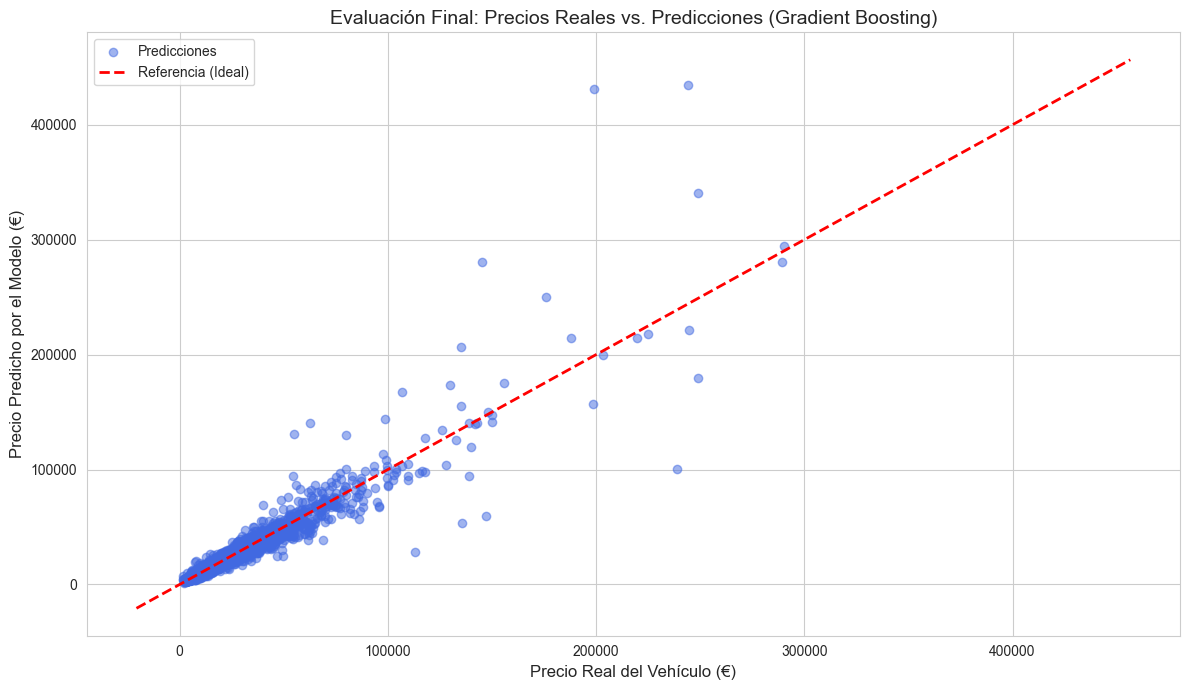

In [15]:
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

plt.scatter(
    y_test, 
    y_pred_gb_opt, 
    alpha=0.5, 
    color='royalblue', 
    label='Predicciones')

lims = [min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1])]
plt.plot(
    lims, 
    lims,
    color='red', 
    linestyle='--', 
    lw=2, 
    label='Referencia (Ideal)')

plt.title('Evaluación Final: Precios Reales vs. Predicciones (Gradient Boosting)', fontsize=14)
plt.xlabel('Precio Real del Vehículo (€)', fontsize=12)
plt.ylabel('Precio Predicho por el Modelo (€)', fontsize=12)
plt.legend()
plt.tight_layout()

plt.show()

- La Diagonal de Referencia: La línea roja discontinua representa la perfección (donde el precio real y la predicción coinciden exactamente). Cuanto más cerca estén los puntos azules de esta línea, más preciso es nuestro Gradient Boosting. 

- Distribución del Error: La mayoría de los puntos se agrupan muy bien en la zona baja y media de precios. Esto confirma nuestro MAE de 1.773,92 €, demostrando que para la gran masa del mercado el modelo es extremadamente fiable. 

- Zonas de Incertidumbre (Outliers): A partir de los 200.000 €, los puntos empiezan a dispersarse. Esto es totalmente lógico: coches de ese calibre (como un Ferrari o un Porsche de colección) dependen de factores que no tenemos en el dataset, como el estado de la tapicería o si pertenecieron a alguien famoso.

---


## Evaluación final contra test

En esta fase final, ponemos a prueba el modelo optimizado utilizando el conjunto de datos de test (datos que el algoritmo nunca ha visto). Este paso es el "momento de la verdad" para validar si nuestra herramienta de tasación es fiable en el mundo real.

### 1. Comparativa: Baseline vs. Modelo Optimizado

La diferencia entre el modelo de referencia (Regresión Lineal) y nuestro Random Forest Optimizado es abismal:

| Métrica | Baseline (Regresión Lineal) | Modelo Final (GB Optimizado) | Mejora (%) |
| --- | --- | --- | --- |
| R² Score | 0.7670 | 0.8919 | +16.3% |
| MAE (€) | 4.541,09 € | $1.773,92$ € | -60.9% |

### 2. Interpretación de resultados

- Eficacia en el mercado: Lograr un error medio de $1.773,92$ € en un mercado con vehículos de alta gama es un éxito rotundo. El modelo es capaz de ajustar el precio con una precisión muy alta, permitiendo automatizar ofertas de compra de forma segura.

- Robustez del MAE: El hecho de que el MAE sea tan bajo indica que el Gradient Boosting ha aprendido a corregir secuencialmente sus errores, afinando la puntería donde otros modelos más generales suelen fallar.

Desde el punto de vista de una empresa de compraventa o una plataforma tipo marketplace:

Tasación Automática: El modelo es lo suficientemente preciso como para integrarlo en una web de tasación instantánea. Un error de ~1.700 € permite dar una horquilla de precios muy ajustada al cliente.

Detección de "Chollos": Al tener un error tan bajo, si el modelo predice que un coche vale 25.000 € y está anunciado por 23.000 €, la probabilidad de que sea una oportunidad real de negocio es muy alta.

### 3. Posibles limitaciones del modelo

Para ser rigurosos, debemos señalar qué se le escapa a nuestro algoritmo:

Estado de conservación: El modelo no sabe si el coche tiene "un rayón" en la puerta, si el interior está impecable o si ha pasado todas las revisiones en taller oficial. Esto siempre causará una pequeña desviación en el precio real.

Equipamiento específico: Extras de alto valor (techo panorámico, faros láser, sistemas de sonido premium) no están registrados en el dataset y podrían justificar precios por encima de nuestra predicción.

Dinámica de mercado: El modelo es una "foto" del momento actual. Cambios bruscos en la legislación (zonas de bajas emisiones) o crisis de componentes podrían alterar estas predicciones en el futuro.

---

### Persistencia del modelo

Para que nuestro trabajo sea reutilizable sin necesidad de ejecutar todo el entrenamiento de nuevo, guardamos el modelo final optimizado en un archivo binario.

In [16]:
import os

ruta_modelos = '../models/'

nombre_archivo = os.path.join(ruta_modelos, 'modelo_tasacion_coches_v1.joblib')
joblib.dump(best_gb, nombre_archivo)

print(f"¡Modelo guardado con éxito en: {nombre_archivo}")

¡Modelo guardado con éxito en: ../models/modelo_tasacion_coches_v1.joblib


In [17]:
# Comprobación de carga
modelo_cargado = joblib.load('../models/modelo_tasacion_coches_v1.joblib')
print(f"Modelo cargado correctamente. Tipo: {type(modelo_cargado)}")

Modelo cargado correctamente. Tipo: <class 'sklearn.ensemble._gb.GradientBoostingRegressor'>
